# Sesi 07 - Data Cleaning

Data cleaning adalah proses membersihkan data sebelum dilakukan analisis
Data kotor menghasilkan analisis yang salah
Membersihkan data adalah hal dan skill yang harus dimiliki sebelum analisis data lebih lanjut

Beberapa langkah dan caranya diantaranya adalah berikut:
1. Handle missing values (data kosong)
2. Handle diplikat data
3. Fix tipe data
4. Handle outlier

## 1. Buat data kotor (simulasi)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
# Buat data yang "sengaja" kotor
data = {
    "nama": ["Andi", "Budi", "Citra", "Andi", "Deni", None, "Endra"],
    "umur": [25, None, 31, 42, 26, 299, 39],
    "kota": ["Jakarta", "bandung", "JAKARTA", "Jakarta", "Surabaya", "Bandung", "SURABAYA"],
    "gaji": [50000000, 66000000, None, 50000000, 99999999, 45000000, 55500000]
}

df = pd.DataFrame(data)
print(df)
print("\nInfo:")
print(df.isnull().sum())

    nama   umur      kota        gaji
0   Andi   25.0   Jakarta  50000000.0
1   Budi    NaN   bandung  66000000.0
2  Citra   31.0   JAKARTA         NaN
3   Andi   42.0   Jakarta  50000000.0
4   Deni   26.0  Surabaya  99999999.0
5   None  299.0   Bandung  45000000.0
6  Endra   39.0  SURABAYA  55500000.0

Info:
nama    1
umur    1
kota    0
gaji    1
dtype: int64


## 2. Handle missing values (data kosong)

In [9]:
#Isi missing values kolom umur dengan nilai tengahnya (median)
df["umur"] = df["umur"].fillna(df["umur"].median())

In [11]:
#Isi missing values kolom gaji dengan nilai tengahnya (median)
df["gaji"] = df["gaji"].fillna(df["gaji"].median())

## 3. Fix inkonsistensi teks dan hasil yang masih duplikat

In [13]:
#Standardisasi kota - huruf kapital di awal kata saja
df["kota"] = df["kota"].str.title()

In [15]:
#Menghapus duplikat
df = df.drop_duplicates()

In [17]:
print(df)
print("\nShape setelah hapus duplikat: ", df.shape)

    nama   umur      kota        gaji
0   Andi   25.0   Jakarta  50000000.0
1   Budi   35.0   Bandung  66000000.0
2  Citra   31.0   Jakarta  52750000.0
3   Andi   42.0   Jakarta  50000000.0
4   Deni   26.0  Surabaya  99999999.0
5   None  299.0   Bandung  45000000.0
6  Endra   39.0  Surabaya  55500000.0

Shape setelah hapus duplikat:  (7, 4)


## 4. Hanle Outlier

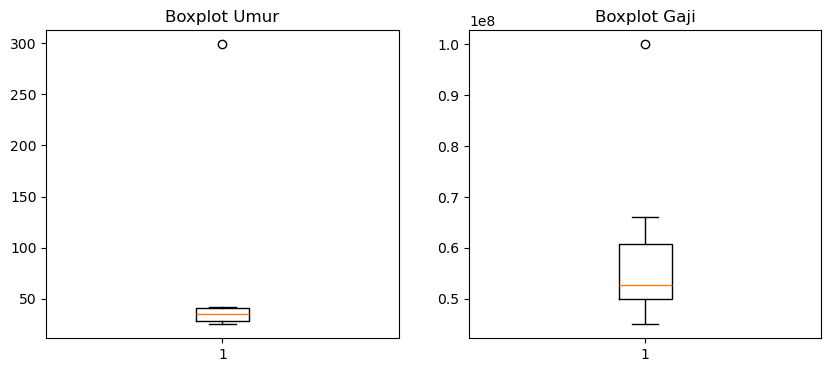

In [19]:
# Cek outlier dengan dilakukan visualisasi
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))
ax1.boxplot(df["umur"])
ax1.set_title("Boxplot Umur")
ax2.boxplot(df["gaji"])
ax2.set_title("Boxplot Gaji")
plt.show()

In [21]:
# Hapus outlier umur (wajarnya adalah 25-45)
df = df[(df["umur"] >= 25) & (df["umur"] <=45)] 

In [23]:
# Hapus outlier gaji (wajarnya < 70 juta
df = df[df["gaji"] <= 70000000]

In [25]:
print("\nData bersih: ")
print(df)
print("\nShape akhir: ", df.shape)


Data bersih: 
    nama  umur      kota        gaji
0   Andi  25.0   Jakarta  50000000.0
1   Budi  35.0   Bandung  66000000.0
2  Citra  31.0   Jakarta  52750000.0
3   Andi  42.0   Jakarta  50000000.0
6  Endra  39.0  Surabaya  55500000.0

Shape akhir:  (5, 4)
